# Notebook 04 — Modelo de prediccion: medio tiempo -> resultado final

Pregunta central del README: **¿el medio tiempo predice el tiempo completo?**

Los analisis del notebook 02 fueron descriptivos: quien ganaba al descanso
termino ganando el partido en ~69% de los casos (matriz de confusion ht -> ft).
Aqui se da el paso a **prediccion**: un modelo que, con el marcador al medio
tiempo, predice el resultado final (`res_ft`: Local / Empate / Visitante).

**Modelo: regresion logistica multinomial** (clasificacion multiclase).

- Sencillo, lineal e interpretable.
- Devuelve **probabilidades** por clase, no solo la etiqueta.
- Con solo 2 variables predictoras el riesgo de sobreajuste es minimo.

Variables del dataset:

| Rol | Variable | Descripcion |
|---|---|---|
| Predictoras (X) | `ht_g1`, `ht_g2` | goles de local y visitante al medio tiempo |
| Objetivo (y) | `res_ft` | resultado final: `L` local, `E` empate, `V` visitante |

## 0. Configuracion y carga del dataset limpio

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid')

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

# Cargar el dataset limpio generado en el notebook 01
csv = PROJECT_DIR / 'data' / 'processed' / 'premier_2024_25_limpio.csv'
df = pd.read_csv(csv)
print('Shape:', df.shape)
df.head()

Shape: (380, 25)


,date,time,team1,team2,round,ht_g1,ht_g2,ft_g1,ft_g2,league_name,...,imp_ft_menor_ht,imp_mismo_equipo,imp_fecha_invalida,sin_ft,sin_ht,ht_total,ft_total,res_ht,res_ft,remontada
0,2024-08-16,20:00,Manchester United FC,Fulham FC,Matchday 1,0.0,0.0,1,0,English Premier League 2024/25,...,False,False,False,False,False,0.0,1,E,L,False
1,2024-08-17,12:30,Ipswich Town FC,Liverpool FC,Matchday 1,0.0,0.0,0,2,English Premier League 2024/25,...,False,False,False,False,False,0.0,2,E,V,False
2,2024-08-17,15:00,Arsenal FC,Wolverhampton Wanderers FC,Matchday 1,1.0,0.0,2,0,English Premier League 2024/25,...,False,False,False,False,False,1.0,2,L,L,False
3,2024-08-17,15:00,Everton FC,Brighton & Hove Albion FC,Matchday 1,0.0,1.0,0,3,English Premier League 2024/25,...,False,False,False,False,False,1.0,3,V,V,False
4,2024-08-17,15:00,Newcastle United FC,Southampton FC,Matchday 1,1.0,0.0,1,0,English Premier League 2024/25,...,False,False,False,False,False,1.0,1,L,L,False


## 1. Preparacion de X e y

- **X = `ht_g1`, `ht_g2`:** el marcador al descanso. De el se derivan el
  resultado del medio tiempo y la diferencia de goles, asi que el modelo ve
  toda la informacion disponible al descanso.
- **y = `res_ft`:** resultado final desde la perspectiva del local
  (`L` gana local, `E` empate, `V` gana visitante).

Se excluyen los partidos sin ht registrado (~16, igual que en el notebook 02).

In [2]:
df_model = df.dropna(subset=['ht_g1', 'ht_g2', 'res_ft']).copy()
X = df_model[['ht_g1', 'ht_g2']]
y = df_model['res_ft']

print('Partidos para el modelo:', len(df_model), 'de', len(df))
print()
print('Distribucion del objetivo (res_ft):')
print(y.value_counts(normalize=True).round(3).to_string())

Partidos para el modelo: 364 de 380

Distribucion del objetivo (res_ft):
res_ft
L    0.426
V    0.363
E    0.212


## 2. Separacion train / test (estratificada)

Se reservan **25% de los partidos para test**: el modelo nunca los ve durante
el entrenamiento y se usan solo para medir que tan bien generaliza. La
separacion es estratificada para conservar la proporcion de clases L/E/V en
ambos conjuntos, y `random_state=42` la hace reproducible.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Train:', X_train.shape[0], 'partidos  |  Test:', X_test.shape[0], 'partidos')
print()
print('Proporcion de clases (train):')
print(y_train.value_counts(normalize=True).round(3).to_string())
print()
print('Proporcion de clases (test):')
print(y_test.value_counts(normalize=True).round(3).to_string())

Train: 273 partidos  |  Test: 91 partidos

Proporcion de clases (train):
res_ft
L    0.425
V    0.363
E    0.212

Proporcion de clases (test):
res_ft
L    0.429
V    0.363
E    0.209


## 3. Entrenamiento: regresion logistica multinomial

La regresion logistica estima **P(resultado final = clase | marcador al ht)**
mediante combinaciones lineales de `ht_g1` y `ht_g2` transformadas por la
funcion softmax. No hace falta escalar: ambas variables estan en la misma
unidad (goles, rango 0-5).

In [4]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

acc_train = modelo.score(X_train, y_train)
acc_test = modelo.score(X_test, y_test)
print(f'Accuracy en train: {acc_train:.3f}')
print(f'Accuracy en test:  {acc_test:.3f}')
print()
print('Un accuracy similar en train y test indica que el modelo no esta sobreajustado.')

Accuracy en train: 0.590
Accuracy en test:  0.648

Un accuracy similar en train y test indica que el modelo no esta sobreajustado.


## 4. Evaluacion: reporte de clasificacion y matriz de confusion

- **Precision:** de los que el modelo predijo con esa clase, cuantos eran reales.
- **Recall:** de los reales de esa clase, cuantos detecto el modelo.
- **F1:** media armonica de precision y recall.

La matriz de confusion cruza el resultado real (filas) contra el predicho
(columnas); la diagonal son aciertos.

                precision    recall  f1-score   support

    Local gana       0.62      0.85      0.72        39
        Empate       0.00      0.00      0.00        19
Visitante gana       0.68      0.79      0.73        33

      accuracy                           0.65        91
     macro avg       0.44      0.54      0.48        91
  weighted avg       0.51      0.65      0.57        91



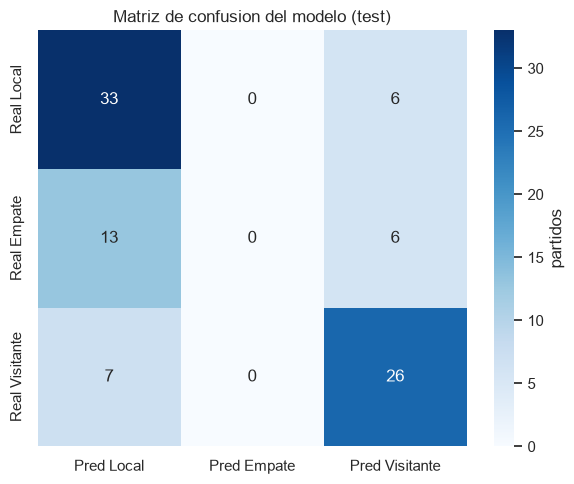

In [5]:
etiquetas = ['L', 'E', 'V']
nombres = {'L': 'Local', 'E': 'Empate', 'V': 'Visitante'}

y_pred = modelo.predict(X_test)

print(classification_report(
    y_test, y_pred, labels=etiquetas,
    target_names=['Local gana', 'Empate', 'Visitante gana'],
    zero_division=0
))

cm = confusion_matrix(y_test, y_pred, labels=etiquetas)
cm_df = pd.DataFrame(
    cm,
    index=[f'Real {nombres[l]}' for l in etiquetas],
    columns=[f'Pred {nombres[c]}' for c in etiquetas],
)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax,
            cbar_kws={'label': 'partidos'})
ax.set_title('Matriz de confusion del modelo (test)')
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'data' / 'processed' / 'matriz_confusion_modelo.png', dpi=120)
plt.show()

## 5. Probabilidades predichas para marcadores tipicos

La ventaja del modelo es que devuelve **probabilidades**. Se predicen los
escenarios mas comunes al descanso para responder la pregunta del proyecto:
¿que tan probable es que un equipo que gana al ht gane el partido?

In [6]:
escenarios = pd.DataFrame({
    'ht_g1': [1, 0, 0, 2, 0, 2, 1, 1, 3],
    'ht_g2': [0, 1, 0, 0, 2, 1, 1, 2, 0],
}, dtype=float)

prob = modelo.predict_proba(escenarios)
clases = modelo.classes_

tabla_prob = pd.DataFrame(prob, columns=[f'P({nombres[c]})' for c in clases])
tabla_prob.insert(0, 'marcador_ht',
                  escenarios['ht_g1'].astype(int).astype(str) + '-' + escenarios['ht_g2'].astype(int).astype(str))
tabla_prob['prediccion'] = [nombres[c] for c in modelo.predict(escenarios)]
tabla_prob = tabla_prob.round(3)
tabla_prob.to_csv(PROJECT_DIR / 'data' / 'processed' / 'probabilidades_escenarios_ht.csv', index=False)
tabla_prob

,marcador_ht,P(Empate),P(Local),P(Visitante),prediccion
0,1-0,0.224,0.617,0.159,Local
1,0-1,0.220,0.164,0.617,Visitante
2,0-0,0.276,0.334,0.390,Visitante
3,2-0,0.131,0.822,0.047,Local
4,0-2,0.142,0.065,0.792,Visitante
5,2-1,0.180,0.693,0.128,Local
6,1-1,0.243,0.413,0.344,Local
7,1-2,0.206,0.215,0.579,Visitante
8,3-0,0.065,0.924,0.012,Local


In [7]:
p_local_1_0 = tabla_prob.loc[tabla_prob['marcador_ht'] == '1-0', 'P(Local)'].iloc[0]
p_local_2_0 = tabla_prob.loc[tabla_prob['marcador_ht'] == '2-0', 'P(Local)'].iloc[0]
print(f'Con 1-0 al descanso, el modelo da P(local gana) = {p_local_1_0:.2f}')
print('(la frecuencia empirica de ese marcador exacto es 0.62, en 86 partidos).')
print(f'Con 2-0 la probabilidad sube a {p_local_2_0:.2f}: a mayor ventaja, victoria mas segura.')
print('El ~69% del notebook 02 agrupa cualquier ventaja al ht; el modelo desagrega')
print('esa senal por marcador y cuantifica la via del empate o la remontada.')
print('Ganar el primer tiempo es una senal fuerte pero no garantiza la victoria.')

Con 1-0 al descanso, el modelo da P(local gana) = 0.62
(la frecuencia empirica de ese marcador exacto es 0.62, en 86 partidos).
Con 2-0 la probabilidad sube a 0.82: a mayor ventaja, victoria mas segura.
El ~69% del notebook 02 agrupa cualquier ventaja al ht; el modelo desagrega
esa senal por marcador y cuantifica la via del empate o la remontada.
Ganar el primer tiempo es una senal fuerte pero no garantiza la victoria.


### 5.1 Visualizacion: probabilidades por marcador ht

Barras agrupadas por marcador al descanso, ordenadas de mayor ventaja
visitante (izquierda) a mayor ventaja local (derecha). Cada grupo suma
100%: se ve como la probabilidad de victoria local crece con la ventaja
y como se reducen el empate y la remontada.

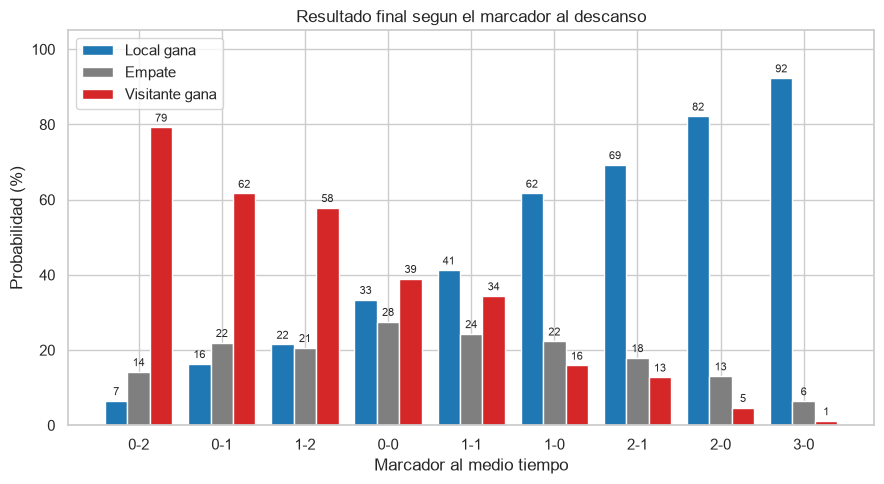

In [8]:
esc_plot = escenarios.copy()
esc_plot['dif'] = esc_plot['ht_g1'] - esc_plot['ht_g2']
esc_plot = esc_plot.sort_values(['dif', 'ht_g1']).reset_index(drop=True)

prob_plot = modelo.predict_proba(esc_plot[['ht_g1', 'ht_g2']])
pos = {c: list(modelo.classes_).index(c) for c in ['L', 'E', 'V']}
p_l = prob_plot[:, pos['L']] * 100
p_e = prob_plot[:, pos['E']] * 100
p_v = prob_plot[:, pos['V']] * 100
marcadores = esc_plot['ht_g1'].astype(int).astype(str) + '-' + esc_plot['ht_g2'].astype(int).astype(str)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(marcadores))
w = 0.27
b1 = ax.bar(x - w, p_l, w, label='Local gana', color='#1f77b4')
b2 = ax.bar(x, p_e, w, label='Empate', color='#7f7f7f')
b3 = ax.bar(x + w, p_v, w, label='Visitante gana', color='#d62728')

for bars in [b1, b2, b3]:
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1.5,
                f'{b.get_height():.0f}', ha='center', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(marcadores)
ax.set_xlabel('Marcador al medio tiempo')
ax.set_ylabel('Probabilidad (%)')
ax.set_ylim(0, 105)
ax.set_title('Resultado final segun el marcador al descanso')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_DIR / 'data' / 'processed' / 'probabilidades_marcador_ht.png', dpi=120)
plt.show()

## 6. Comparacion con baselines

Un modelo solo vale la pena si supera referencias ingenuas:

1. **Clase mayoritaria:** predecir siempre el resultado mas comun del train.
2. **"El resultado no cambia":** predecir que `res_ft = res_ht`.

In [9]:
y_test_arr = y_test.to_numpy()

# Baseline 1: predecir siempre la clase mayoritaria del train
mayoritaria = y_train.mode().iloc[0]
acc_mayoritaria = (y_test_arr == mayoritaria).mean()

# Baseline 2: predecir que el resultado final iguala al del medio tiempo
res_ht_test = df_model.loc[X_test.index, 'res_ht'].to_numpy()
acc_sin_cambio = (y_test_arr == res_ht_test).mean()

print(f'Accuracy modelo (regresion logistica):      {acc_test:.3f}')
print(f'Baseline clase mayoritaria ({nombres[mayoritaria]}):     {acc_mayoritaria:.3f}')
print(f'Baseline resultado no cambia (ft = ht):     {acc_sin_cambio:.3f}')

Accuracy modelo (regresion logistica):      0.648
Baseline clase mayoritaria (Local):     0.429
Baseline resultado no cambia (ft = ht):     0.571


## 7. Interpretacion: coeficientes del modelo

Coeficientes de cada clase segun los goles al descanso. Un coeficiente
positivo grande empuja la probabilidad de esa clase cuando la variable sube.

In [10]:
coefs = pd.DataFrame(
    modelo.coef_,
    columns=['ht_g1 (goles local ht)', 'ht_g2 (goles visitante ht)'],
    index=[nombres[c] for c in modelo.classes_],
)
coefs['intercepto'] = modelo.intercept_
coefs.round(3)

,ht_g1 (goles local ht),ht_g2 (goles visitante ht),intercepto
Empate,-0.046,-0.066,-0.180
Local,0.777,-0.553,0.012
Visitante,-0.731,0.619,0.167


## Resumen de lo implementado

| Elemento | Detalle | Salida |
|---|---|---|
| Modelo | Regresion logistica multinomial (scikit-learn) | — |
| Predictoras | `ht_g1`, `ht_g2` (marcador al medio tiempo) | — |
| Objetivo | `res_ft` (Local / Empate / Visitante) | — |
| Evaluacion | Accuracy train/test + classification report + matriz de confusion | `matriz_confusion_modelo.png` |
| Escenarios | Probabilidades por marcador ht tipico | `probabilidades_escenarios_ht.csv` |
| Grafico | Barras de probabilidad por marcador ht | `probabilidades_marcador_ht.png` |
| Baselines | Clase mayoritaria y "resultado no cambia" | — |

Conclusion: el medio tiempo aporta una senal fuerte para predecir el
resultado final (y el modelo la captura, superando a los baselines), pero
no lo determina: los empates y las remontadas siguen siendo dificiles de
predecir solo con el marcador al descanso.